<a href="https://colab.research.google.com/github/innaraarif26-create/GemAI/blob/main/gemstone_vit_classification_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer (ViT) for Gemstone Classification
### 20-Class Gemstone Detection | ~14,000-16,000 Images | Transfer Learning + MC Dropout

**Dataset structure expected:**
```
gemstones/
├── ruby/        (~700-800 images)
├── emerald/     (~700-800 images)
├── sapphire/    (~700-800 images)
... (20 folders total)
```

## Step 1: Install Dependencies

In [ ]:
!pip install timm scikit-learn matplotlib seaborn torch torchvision -q

## Step 2: Mount Google Drive & Set Dataset Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# =============================================
# UPDATE THIS PATH to your dataset location
# =============================================
DATASET_PATH = '/content/drive/MyDrive/dataset'  # <-- change this
# OR if uploading ZIP directly:
# !unzip /content/drive/MyDrive/gemstones.zip -d /content/
# DATASET_PATH = '/content/gemstones'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3: Imports & Device Setup

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm

from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, classification_report
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Step 4: Data Preprocessing
*(224x224 resize, ImageNet normalization — same as paper)*

In [ ]:
# ImageNet mean/std — required for pretrained ViT (same as paper)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224
BATCH_SIZE    = 32   # same as paper — works well with 700-800 images/class
EPOCHS        = 15   # sufficient for large dataset with pretrained weights
LR            = 1e-4

# Training transforms — moderate augmentation (large dataset needs less)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation transforms — no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Load full dataset from folder structure
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Total images  : {len(full_dataset)}')
print(f'Total classes : {NUM_CLASSES}')
print(f'Classes       : {CLASS_NAMES}')

Total images  : 16475
Total classes : 20
Classes       : ['Alexandrite', 'Amber', 'Cats Eye', 'Malachite', 'Morganite', 'aquamarine', 'diamond', 'emerald', 'fluorite green', 'fluorite purple', 'garnet', 'peridot', 'ruby', 'sapphire blue', 'sapphire pink', 'topaz blue', 'topaz yellow', 'tourmaline black', 'turquoise', 'zircon']


## Step 5: Dataset Visualization — Class Distribution

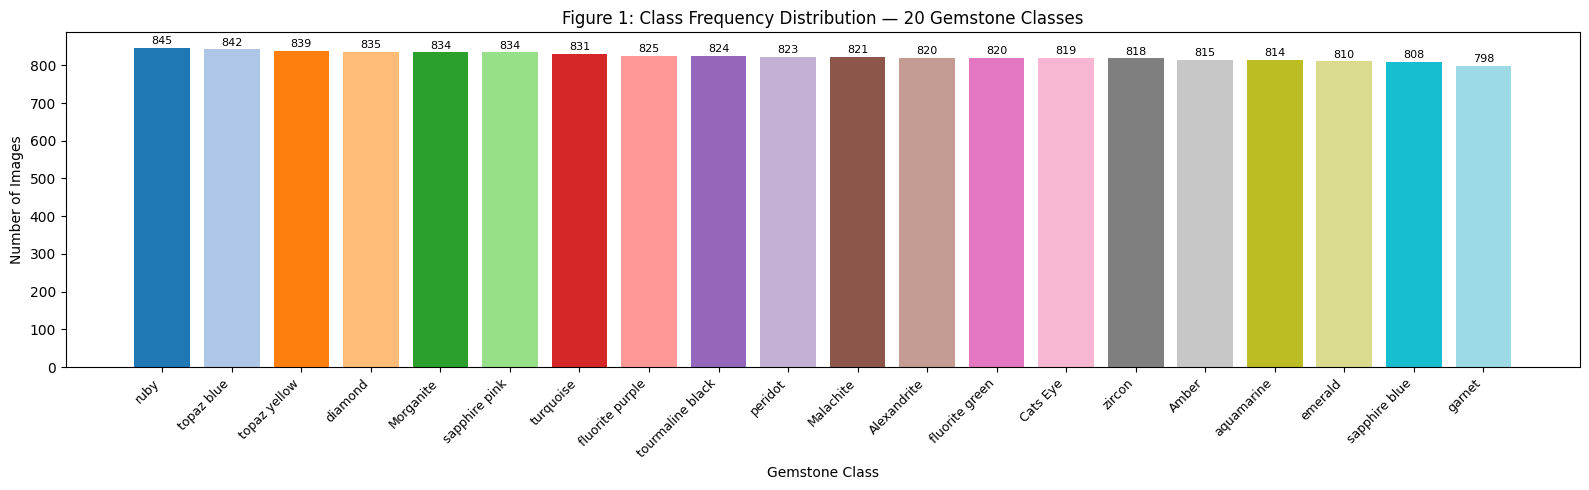

Average images per class: 824
Min: 798 | Max: 845


In [ ]:
# Count images per class
label_counts  = Counter([label for _, label in full_dataset.samples])
sorted_counts = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
classes_sorted = [CLASS_NAMES[i] for i, _ in sorted_counts]
counts_sorted  = [c for _, c in sorted_counts]

plt.figure(figsize=(16, 5))
bars = plt.bar(classes_sorted, counts_sorted,
               color=plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES)))
for bar, count in zip(bars, counts_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.xlabel('Gemstone Class')
plt.ylabel('Number of Images')
plt.title('Figure 1: Class Frequency Distribution — 20 Gemstone Classes')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(f'Average images per class: {np.mean(counts_sorted):.0f}')
print(f'Min: {min(counts_sorted)} | Max: {max(counts_sorted)}')

## Step 6: Sample Image Grid — One Per Class

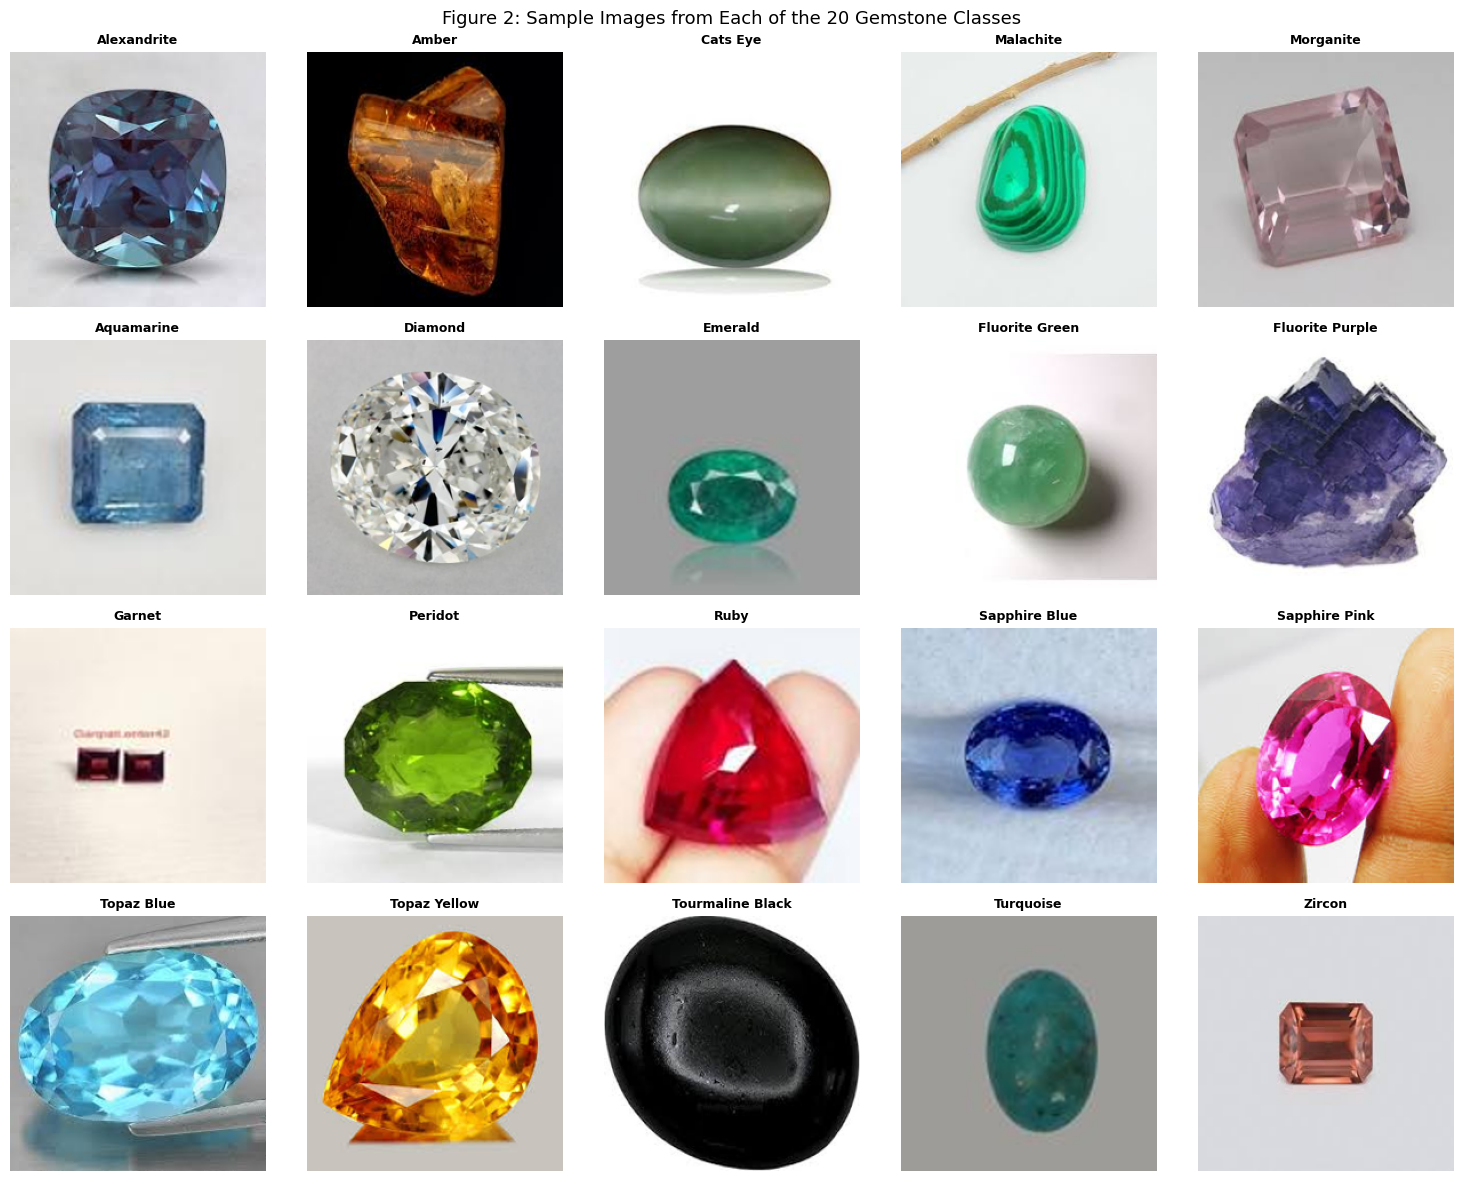

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_PATH, class_name)
    imgs = [f for f in os.listdir(class_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    img_path = os.path.join(class_dir, random.choice(imgs))
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[idx].imshow(img)
    axes[idx].set_title(class_name.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Figure 2: Sample Images from Each of the 20 Gemstone Classes', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Step 7: Train / Validation Split — 80% / 20%
*(Same ratio as paper: Section V.A)*

In [ ]:
total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply val transforms to validation subset
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

print(f'Total images      : {total:,}')
print(f'Training samples  : {train_size:,} (80%)')
print(f'Validation samples: {val_size:,} (20%)')
print(f'Batch size        : {BATCH_SIZE}')
print(f'Train batches/epoch: {len(train_loader)}')

Total images      : 16,475
Training samples  : 13,180 (80%)
Validation samples: 3,295 (20%)
Batch size        : 32
Train batches/epoch: 412


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Step 8: ViT Model Architecture
*(Section V.A — deit_base_patch16_224, pretrained ImageNet, 20-class head with MC Dropout)*

In [ ]:
class GemstoneViT(nn.Module):
    """
    Vision Transformer for 20-class Gemstone Classification.
    Uses deit_base_patch16_224 backbone (same as paper).
    MC Dropout layers enable uncertainty estimation at inference.
    """
    def __init__(self, num_classes=20, dropout_rate=0.3):
        super(GemstoneViT, self).__init__()
        # Pretrained DeiT backbone — same as paper
        self.vit = timm.create_model(
            'deit_base_patch16_224',
            pretrained=True,
            num_classes=0       # remove original 1000-class head
        )
        embed_dim = self.vit.num_features  # 768 for base model

        # Custom classification head with Dropout for MC Dropout
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(p=dropout_rate),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.vit(x)             # (B, 768)
        return self.classifier(features)   # (B, num_classes)


model = GemstoneViT(num_classes=NUM_CLASSES, dropout_rate=0.3).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model on device     : {DEVICE}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters    : 86,204,180
Trainable parameters: 86,204,180
Model on device     : cuda


## Step 9: Training Setup
*(Section V.B — AdamW + StepLR + CrossEntropyLoss)*

In [ ]:
criterion = nn.CrossEntropyLoss()  # single-label classification
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds   = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print(f'Optimizer : AdamW  | LR: {LR}')
print(f'Scheduler : StepLR | step=5, gamma=0.5')
print(f'Loss      : CrossEntropyLoss')
print(f'Epochs    : {EPOCHS}')

Optimizer : AdamW  | LR: 0.0001
Scheduler : StepLR | step=5, gamma=0.5
Loss      : CrossEntropyLoss
Epochs    : 15


## Step 10: Training Loop

In [ ]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc%':>11} {'Val Loss':>10} {'Val Acc%':>10} {'LR':>10}")
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc          = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, _, _   = evaluate(model, val_loader, criterion)
    current_lr               = scheduler.get_last_lr()[0]
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    # Save best model checkpoint
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_gemstone_vit.pth')
        flag = ' ← best'
    else:
        flag = ''

    print(f"{epoch:>6} {tr_loss:>12.4f} {tr_acc*100:>10.2f}% {vl_loss:>10.4f} {vl_acc*100:>9.2f}% {current_lr:>10.2e}{flag}")

print(f'\nBest Validation Accuracy: {best_val_acc*100:.2f}%')

 Epoch   Train Loss  Train Acc%   Val Loss   Val Acc%         LR
-----------------------------------------------------------------


NameError: name 'EPOCHS' is not defined

## Step 11: Training & Validation Curves

In [ ]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, val_losses,   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Figure 3: Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs_range, [a*100 for a in train_accs], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in val_accs],   'r-o', label='Val Acc',   linewidth=2)
axes[1].axhline(y=best_val_acc*100, color='green', linestyle='--', alpha=0.7,
                label=f'Best Val: {best_val_acc*100:.2f}%')
axes[1].set_title('Figure 4: Training & Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Step 12: Evaluation Metrics
*(Section V.B — Precision, Recall, F1, F2, Misclassification Rate)*

In [ ]:
# Load best saved model
model.load_state_dict(torch.load('best_gemstone_vit.pth'))
_, val_acc, all_preds, all_labels = evaluate(model, val_loader, criterion)

precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall    = recall_score(all_labels,    all_preds, average='macro', zero_division=0)
f1        = f1_score(all_labels,        all_preds, average='macro', zero_division=0)
f2        = fbeta_score(all_labels,     all_preds, beta=2, average='macro', zero_division=0)
misclass  = 1 - val_acc

print('=' * 50)
print('   EVALUATION RESULTS — ViT Gemstone Model')
print('=' * 50)
print(f'Accuracy              : {val_acc:.4f}  ({val_acc*100:.2f}%)')
print(f'Precision (macro)     : {precision:.4f}')
print(f'Recall (macro)        : {recall:.4f}')
print(f'F1 Score (macro)      : {f1:.4f}')
print(f'F2 Score (macro)      : {f2:.4f}')
print(f'Misclassification Rate: {misclass:.4f}  ({misclass*100:.2f}%)')
print('=' * 50)

# Store for later comparison
vit_results = {
    'Accuracy':               val_acc,
    'Precision (macro)':      precision,
    'Recall (macro)':         recall,
    'F1 Score (macro)':       f1,
    'F2 Score (macro)':       f2,
    'Misclassification Rate': misclass
}

## Step 13: Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Figure 5: Confusion Matrix — ViT Gemstone Classification (20 Classes)', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 14: Per-Class Classification Report

In [ ]:
report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    zero_division=0
)
print(report)

# Per-class F1 bar chart
from sklearn.metrics import f1_score as f1_per
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

plt.figure(figsize=(14, 5))
bars = plt.bar(CLASS_NAMES, per_class_f1,
               color=['#2ecc71' if f >= 0.8 else '#e67e22' if f >= 0.6 else '#e74c3c'
                      for f in per_class_f1])
plt.axhline(y=np.mean(per_class_f1), color='blue', linestyle='--',
            label=f'Mean F1: {np.mean(per_class_f1):.3f}')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.title('Figure 6: Per-Class F1 Score — ViT Gemstone Model')
plt.legend()
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150)
plt.show()

## Step 15: Monte Carlo Dropout — Uncertainty Estimation
*(Section VII — 30 stochastic forward passes, std dev = epistemic uncertainty)*

In [ ]:
def enable_dropout(model):
    """Keep dropout active during inference for MC Dropout."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def mc_dropout_predict(model, image_tensor, n_passes=30):
    """
    Monte Carlo Dropout Inference.
    Returns:
        mean_probs  : mean probability per class across N passes
        uncertainty : std deviation per class (epistemic uncertainty)
    """
    model.eval()
    enable_dropout(model)
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(image_tensor)
            probs  = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
    all_probs   = np.array(all_probs).squeeze()   # (n_passes, num_classes)
    mean_probs  = all_probs.mean(axis=0)
    uncertainty = all_probs.std(axis=0)
    return mean_probs, uncertainty

print('MC Dropout inference functions ready.')

## Step 16: Uncertainty Visualization
*(Equivalent to paper Figure + Table — Top-5 predictions with uncertainty)*

In [ ]:
def visualize_uncertainty(image_path, true_label=None, n_passes=30):
    img    = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img)

    mean_probs, uncertainty = mc_dropout_predict(model, tensor, n_passes)

    top5_idx  = mean_probs.argsort()[::-1][:5]
    top5_prob = mean_probs[top5_idx]
    top5_unc  = uncertainty[top5_idx]
    top5_cls  = [CLASS_NAMES[i] for i in top5_idx]
    predicted = CLASS_NAMES[top5_idx[0]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: image
    axes[0].imshow(img.resize((224, 224)))
    axes[0].axis('off')
    title = f'Predicted: {predicted}'
    if true_label:
        correct = '✓' if predicted == true_label else '✗'
        title  += f'  |  True: {true_label} {correct}'
    axes[0].set_title(title, fontsize=11, fontweight='bold')

    # Right panel: uncertainty bar chart
    colors = ['#2ecc71'] + ['#3498db'] * 4
    axes[1].barh(
        top5_cls[::-1], top5_prob[::-1],
        xerr=top5_unc[::-1],
        color=colors[::-1], capsize=6, alpha=0.85
    )
    axes[1].set_xlabel('Probability')
    axes[1].set_title(f'Top-5 Predictions (MC Dropout, {n_passes} passes)', fontsize=11)
    axes[1].set_xlim(0, 1.05)
    axes[1].grid(axis='x', alpha=0.3)
    for i, (p, u) in enumerate(zip(top5_prob[::-1], top5_unc[::-1])):
        axes[1].text(p + 0.02, i, f'{p:.3f} \u00b1 {u:.3f}', va='center', fontsize=9)

    plt.suptitle('Figure 7: ViT Prediction with Monte Carlo Uncertainty Estimation', fontsize=12)
    plt.tight_layout()
    plt.savefig('uncertainty_prediction.png', dpi=150)
    plt.show()

    # Paper-style table
    print(f"\n{'Class':<22} {'Probability':>12} {'Uncertainty':>14}")
    print('-' * 52)
    for cls, prob, unc in zip(top5_cls, top5_prob, top5_unc):
        conf = 'HIGH' if unc < 0.02 else 'MED' if unc < 0.05 else 'LOW'
        print(f"{cls:<22} {prob:>12.4f} {f'\u00b1 {unc:.4f}':>14}  [{conf} confidence]")


# Run on one sample image automatically
sample_class = CLASS_NAMES[0]
sample_dir   = os.path.join(DATASET_PATH, sample_class)
sample_imgs  = [f for f in os.listdir(sample_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
sample_path  = os.path.join(sample_dir, sample_imgs[0])
visualize_uncertainty(sample_path, true_label=sample_class, n_passes=30)

## Step 17: CNN vs ViT Comparison
*(Enter your CNN results below — this is your paper's key Table)*

In [ ]:
# ============================================================
# FILL IN YOUR CNN RESULTS HERE (from your previous work)
# ============================================================
cnn_results = {
    'Accuracy':               0.00,   # e.g. 0.82
    'Precision (macro)':      0.00,   # e.g. 0.79
    'Recall (macro)':         0.00,   # e.g. 0.77
    'F1 Score (macro)':       0.00,   # e.g. 0.78
    'F2 Score (macro)':       0.00,   # e.g. 0.77
    'Misclassification Rate': 0.00,   # e.g. 0.18
}

# Print comparison table
metrics = list(vit_results.keys())
print(f"{'Metric':<30} {'CNN (Baseline)':>16} {'ViT (Proposed)':>16} {'Improvement':>14}")
print('=' * 80)
for m in metrics:
    cv, vv = cnn_results[m], vit_results[m]
    if m == 'Misclassification Rate':
        arrow = '\u2193' if vv < cv else '\u2191'
        diff  = f"{arrow} {abs(vv-cv):.4f}"
    else:
        arrow = '\u2191' if vv > cv else '\u2193'
        diff  = f"{arrow} {abs(vv-cv):.4f}"
    print(f"{m:<30} {cv:>16.4f} {vv:>16.4f} {diff:>14}")

# Comparison bar chart
plot_metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)',
                'F1 Score (macro)', 'F2 Score (macro)']
cnn_vals = [cnn_results[m] for m in plot_metrics]
vit_vals = [vit_results[m] for m in plot_metrics]
x = np.arange(len(plot_metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, cnn_vals, w, label='CNN (Baseline)', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + w/2, vit_vals, w, label='ViT (Proposed)', color='#2ecc71', alpha=0.85)

# Value labels on bars
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Figure 8: CNN vs ViT — Performance Comparison on 20-Class Gemstone Dataset')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_vs_vit_comparison.png', dpi=150)
plt.show()

## Step 18: Save All Results

In [ ]:
with open('vit_results_summary.txt', 'w') as f:
    f.write('ViT Gemstone Classification — Results Summary\n')
    f.write('=' * 55 + '\n')
    f.write(f'Model         : deit_base_patch16_224 (pretrained)\n')
    f.write(f'Dataset       : 20-Class Gemstone Dataset\n')
    f.write(f'Total Images  : {total:,}\n')
    f.write(f'Classes       : {NUM_CLASSES}\n')
    f.write(f'Train / Val   : {train_size:,} / {val_size:,}\n')
    f.write(f'Epochs        : {EPOCHS}\n')
    f.write(f'Batch Size    : {BATCH_SIZE}\n')
    f.write(f'Learning Rate : {LR}\n')
    f.write(f'MC Passes     : 30\n\n')
    f.write('METRICS\n')
    f.write('-' * 55 + '\n')
    for k, v in vit_results.items():
        f.write(f'{k:<30}: {v:.4f}\n')

print('All files saved:')
saved_files = [
    ('class_distribution.png',   'Figure 1 — Class frequency bar chart'),
    ('sample_images.png',        'Figure 2 — Sample image grid'),
    ('training_curves.png',      'Figure 3&4 — Loss and accuracy curves'),
    ('confusion_matrix.png',     'Figure 5 — 20x20 confusion matrix'),
    ('per_class_f1.png',         'Figure 6 — Per-class F1 bar chart'),
    ('uncertainty_prediction.png','Figure 7 — MC Dropout uncertainty plot'),
    ('cnn_vs_vit_comparison.png','Figure 8 — CNN vs ViT comparison'),
    ('vit_results_summary.txt',  'Results summary text file'),
    ('best_gemstone_vit.pth',    'Best model weights'),
]
for fname, desc in saved_files:
    print(f'  {fname:<35} — {desc}')